# Hyperpartisan News Detection with RoBERTa

This notebook fine-tunes a RoBERTa model to classify the political bias of news articles.

### 1. Setup and Installation
First, we install and import the necessary libraries. We rely heavily on the Hugging Face ecosystem (`transformers`, `datasets`, `accelerate`) for model training and `scikit-learn` for evaluation metrics.

In [ ]:
!pip install "datasets<3.0.0" transformers torch accelerate scikit-learn

import torch
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

### 2. Dataset Loading and Sampling
We load the `hyperpartisan_news_detection` dataset from SemEval. Since the dataset might be large or imbalanced, we use a stratified subsampling strategy. This function ensures we get an equal number of examples per class (4,000 per class for training, 800 for validation) to prevent the model from biasing toward a majority class.

In [ ]:
dataset = load_dataset(
    "SemEvalWorkshop/hyperpartisan_news_detection",
    "bypublisher",
    trust_remote_code=True
)

def subsample_stratified(split, n_per_class=4000):
    """Pull n_per_class examples per bias label (5 classes = 20k total)."""
    subsets = []
    for label in range(5):
        subset = split.filter(lambda x: x["bias"] == label)
        subset = subset.select(range(min(n_per_class, len(subset))))
        subsets.append(subset)
    return concatenate_datasets(subsets).shuffle(seed=42)

train_data = subsample_stratified(dataset["train"], n_per_class=4000)
val_data = subsample_stratified(dataset["validation"], n_per_class=800)

print(train_data)

Dataset({
    features: ['text', 'title', 'hyperpartisan', 'url', 'published_at', 'bias'],
    num_rows: 20000
})


### 3. Tokenization and Truncation Strategies
News articles can be very long, often exceeding the 512-token limit of models like RoBERTa. Here, we define three different truncation strategies to handle long texts:
*   **`tokenize_first`**: Keeps only the first 512 tokens (the beginning of the article).
*   **`tokenize_last`**: Keeps only the last 512 tokens (the end of the article).
*   **`tokenize_first_last`**: Keeps the first 128 tokens and the last 382 tokens, capturing both the introduction and the conclusion.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
MAX_LEN = 512

def tokenize_first(example):
    combined = example["title"] + " " + example["text"]
    return tokenizer(combined, truncation=True, padding="max_length", max_length=MAX_LEN)

def tokenize_last(example):
    combined = example["title"] + " " + example["text"]
    tokens = tokenizer(combined, truncation=False, add_special_tokens=False)["input_ids"]
    tokens = tokens[-510:]
    tokens = [tokenizer.cls_token_id] + tokens + [tokenizer.sep_token_id]
    padding = [tokenizer.pad_token_id] * (MAX_LEN - len(tokens))
    mask = [1] * len(tokens) + [0] * len(padding)
    return {"input_ids": tokens + padding, "attention_mask": mask}

def tokenize_first_last(example):
    # 128 from front, 382 from back
    combined = example["title"] + " " + example["text"]
    tokens = tokenizer(combined, truncation=False, add_special_tokens=False)["input_ids"]
    if len(tokens) <= 510:
        chunk = tokens
    else:
        chunk = tokens[:128] + tokens[-382:]
    chunk = [tokenizer.cls_token_id] + chunk + [tokenizer.sep_token_id]
    padding = [tokenizer.pad_token_id] * (MAX_LEN - len(chunk))
    mask = [1] * len(chunk) + [0] * len(padding)
    return {"input_ids": chunk + padding, "attention_mask": mask}

# Manually Edit
TRUNCATION_STRATEGY = tokenize_first_last
STRATEGY_NAME = "first_last"

def preprocess(example):
    result = TRUNCATION_STRATEGY(example)
    result["labels"] = example["bias"]
    return result

train_tok = train_data.map(preprocess, remove_columns=train_data.column_names)
val_tok = val_data.map(preprocess,   remove_columns=val_data.column_names)
train_tok.set_format("torch")
val_tok.set_format("torch")

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1271 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

### 4. Evaluation Metrics
We define a custom function to compute metrics during training. We track **Accuracy** and **Macro F1-score**. Macro F1 is particularly useful for multiclass classification as it treats all classes equally, regardless of their support size.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "macro_f1": f1_score(labels, preds, average="macro"),
        "accuracy": accuracy_score(labels, preds),
    }

### 5. Model Initialization and Training
We load the pre-trained `roberta-base` model configured for sequence classification with 5 labels.

The `TrainingArguments` define our hyperparameters: 5 epochs, batch sizes, learning rate, and evaluation strategy. We then initialize the Hugging Face `Trainer` to handle the training loop automatically.

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=5,
)

args = TrainingArguments(
    output_dir=f"./roberta_{STRATEGY_NAME}",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    fp16=True,
    report_to="none",
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_steps=200,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)

trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.307526,2.712393,0.284951,0.285750
2,0.195804,3.474952,0.264269,0.302500
3,0.103569,4.360465,0.263172,0.267500
4,0.026097,5.207973,0.260270,0.274500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=5000, training_loss=0.237676868724823, metrics={'train_runtime': 1259.2243, 'train_samples_per_second': 63.531, 'train_steps_per_second': 3.971, 'total_flos': 2.104945139712e+16, 'train_loss': 0.237676868724823, 'epoch': 4.0})

### 6. Evaluation and Error Analysis
Finally, we generate predictions on the entire validation set. We print out the overall metrics (Macro-F1, Accuracy, Loss) and a detailed per-class classification report.

We also generate a **Confusion Matrix** to help analyze which specific bias categories the model is confusing with one another. The predictions and the best model are saved for future analysis.


Strategy: first_last
  Macro-F1:  0.2828
  Accuracy:  0.2833
  Eval Loss: 2.7353
Classification report saved → ./roberta_first_last_metrics/report_first_last.txt


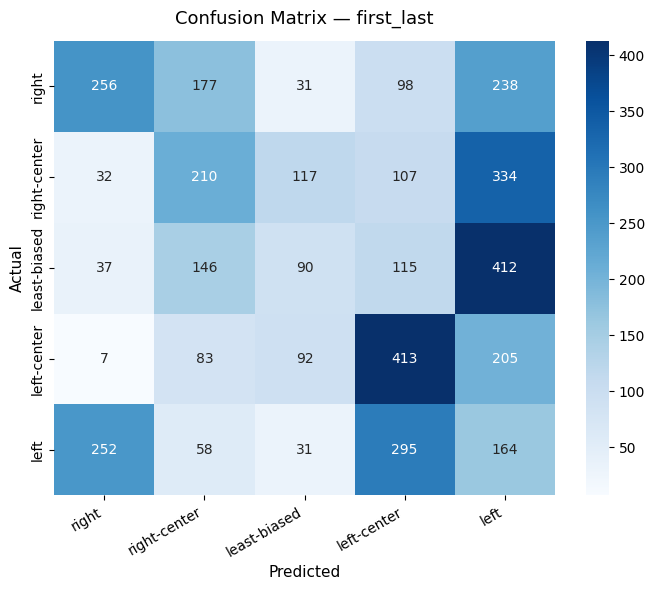

Confusion matrix saved → ./roberta_first_last_metrics/confusion_first_last.png


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and predictions saved.


In [ ]:
# Get predictions
predictions = trainer.predict(val_tok)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

label_names = ["right", "right-center", "least-biased", "left-center", "left"]
results = trainer.evaluate()

output_dir = f"./roberta_{STRATEGY_NAME}_metrics"
os.makedirs(output_dir, exist_ok=True)

print(f"\n{'='*50}")
print(f"Strategy: {STRATEGY_NAME}")
print(f"  Macro-F1:  {results['eval_macro_f1']:.4f}")
print(f"  Accuracy:  {results['eval_accuracy']:.4f}")
print(f"  Eval Loss: {results['eval_loss']:.4f}")
print(f"{'='*50}")

report = classification_report(labels, preds, target_names=label_names)
report_path = f"{output_dir}/report_{STRATEGY_NAME}.txt"

with open(report_path, "w") as f:
    f.write(f"Strategy: {STRATEGY_NAME}\n")
    f.write(f"Macro-F1: {results['eval_macro_f1']:.4f} | ")
    f.write(f"Accuracy: {results['eval_accuracy']:.4f} | ")
    f.write(f"Loss: {results['eval_loss']:.4f}\n\n")
    f.write(report)

print(f"Classification report saved → {report_path}")

cm = confusion_matrix(labels, preds)
cm_path = f"{output_dir}/confusion_{STRATEGY_NAME}.png"

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    ax=ax
)
ax.set_title(f"Confusion Matrix — {STRATEGY_NAME}", fontsize=13, pad=12)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
fig.savefig(cm_path, dpi=150)
plt.show()
print(f"Confusion matrix saved → {cm_path}")

pd.DataFrame({
    "true": [label_names[l] for l in labels],
    "predicted": [label_names[p] for p in preds]
}).to_csv(f"{output_dir}/preds_{STRATEGY_NAME}.csv", index=False)

trainer.save_model(f"{output_dir}/roberta_{STRATEGY_NAME}_best")
print("Model and predictions saved.")